# **3. MODEL TRAINING**

### Importing Libraries

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score, precision_recall_curve
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from xgboost import XGBClassifier
import joblib
import json

### Loading dataset

In [2]:
df = pd.read_csv("new_data.csv")
df.columns

Index(['AccidentArea', 'Sex', 'MaritalStatus', 'Age', 'Fault',
       'VehicleCategory', 'VehiclePrice', 'FraudFound_P', 'Deductible',
       'DriverRating', 'Days_Policy_Accident', 'Days_Policy_Claim',
       'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder',
       'PoliceReportFiled', 'AgentType', 'NumberOfSuppliments',
       'AddressChange_Claim', 'NumberOfCars', 'BasePolicy', 'MonthDelay',
       'DayDelay', 'WeekDelay', 'NoWitnessNoPoliceReport',
       'LessAgeExpensiveVehicle'],
      dtype='str')

### Data Preprocessing

##### Train/Test split

Seperating data

In [4]:
X = df.drop("FraudFound_P", axis=1)
y = df["FraudFound_P"]

Applying train and test split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#### Feature Encoding

In this step, we're gonna encode all our data before passing it through ML pipeline. Here is our encoding strategy:

1. Ordinal columns: Ordinal Encoding
2. Binary columns: Ordinal Encoding (or manual mapping)
3. Numerical columns: Passthrough
4. Categorical columns: One-hot Encoding

##### Getting columns

Getting ordinal columns

In [10]:
ordinal_cols = ["VehiclePrice", "Days_Policy_Accident", "Days_Policy_Claim", "PastNumberOfClaims", "AgeOfVehicle", "AgeOfPolicyHolder", "NumberOfCars", "NumberOfSuppliments", "AddressChange_Claim"]

Getting binary columns

In [17]:
binary_cols = [col for col in X_train.columns if X_train[col].nunique() == 2 and col not in ordinal_cols]

Getting categorical columns

In [23]:
cat_cols = ["VehicleCategory", "BasePolicy"]

Getting numerical columns

In [21]:
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()

Checking all columns

In [24]:
print("Categorical Columns:", cat_cols)
print("Numerical Columns:", num_cols)
print("Ordinal Columns:", ordinal_cols)
print("Binary Columns:", binary_cols)

Categorical Columns: ['VehicleCategory', 'BasePolicy']
Numerical Columns: ['Age', 'Deductible', 'DriverRating', 'MonthDelay', 'DayDelay', 'WeekDelay', 'LessAgeExpensiveVehicle']
Ordinal Columns: ['VehiclePrice', 'Days_Policy_Accident', 'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder', 'NumberOfCars', 'NumberOfSuppliments', 'AddressChange_Claim']
Binary Columns: ['AccidentArea', 'Sex', 'MaritalStatus', 'Fault', 'PoliceReportFiled', 'AgentType', 'NoWitnessNoPoliceReport', 'LessAgeExpensiveVehicle']


##### Creating preprocessor

In [26]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "ord_bin",
            OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
            ordinal_cols + binary_cols,
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            cat_cols
        )
    ],
    remainder="passthrough"
)

### Model Training

#### Testing All Models

Here we're gonna test all the models that might be useful. From there, we'll compare each metric and choose our final model

##### On default parameters

In [27]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42)
}

results = []

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessing', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
results_df.sort_values(by="F1 Score", ascending=False)

d:\Projects\Automobile Insurance Fraud Detection\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.651656,0.127133,0.837079,0.220741
1,Decision Tree,0.898675,0.183168,0.207865,0.194737
4,XGBoost,0.939735,0.437500,0.078652,0.133333
2,Random Forest,0.938742,0.360000,0.050562,0.088670
3,Gradient Boosting,0.942053,0.615385,0.044944,0.083770


##### w/ Hyperparameter tuning

In [28]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        C=0.5,
        penalty="l2",
        solver="liblinear",
        random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        min_samples_split=20,
        min_samples_leaf=10,
        criterion="gini",
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_split=10,
        min_samples_leaf=4,
        max_features="sqrt",
        bootstrap=True,
        n_jobs=-1,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        subsample=0.8,
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=0.2,
        reg_alpha=0.5,
        reg_lambda=1.0,
        eval_metric="logloss",
        random_state=42
    )
}

results = []

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessing', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
results_df.sort_values(by="F1 Score", ascending=False)

d:\Projects\Automobile Insurance Fraud Detection\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.651325,0.127660,0.842697,0.221729
2,Random Forest,0.911258,0.228916,0.213483,0.220930
1,Decision Tree,0.880464,0.172043,0.269663,0.210066
4,XGBoost,0.943709,0.785714,0.061798,0.114583
3,Gradient Boosting,0.943046,0.687500,0.061798,0.113402


##### w/ Threshold tuning

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        C=0.5,
        penalty="l2",
        solver="liblinear",
        random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        min_samples_split=20,
        min_samples_leaf=10,
        criterion="gini",
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_split=10,
        min_samples_leaf=4,
        max_features="sqrt",
        bootstrap=True,
        n_jobs=-1,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        subsample=0.8,
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=0.2,
        reg_alpha=0.5,
        reg_lambda=1.0,
        eval_metric="logloss",
        random_state=42
    )
}

thresholds = np.arange(0.10, 0.91, 0.05)

# Store all results
all_results = []

# Loop through models
for name, model in models.items():

    # Create pipeline
    pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', model)
    ])

    # Train
    pipeline.fit(X_train, y_train)

    # Probability predictions
    y_probs = pipeline.predict_proba(X_test)[:, 1]

    # Test different thresholds
    for threshold in thresholds:

        y_pred_thresh = (y_probs >= threshold).astype(int)

        accuracy = accuracy_score(y_test, y_pred_thresh)
        precision = precision_score(y_test, y_pred_thresh, zero_division=0)
        recall = recall_score(y_test, y_pred_thresh, zero_division=0)
        f1 = f1_score(y_test, y_pred_thresh, zero_division=0)
        roc_auc = roc_auc_score(y_test, y_probs)

        all_results.append({
            "Model": name,
            "Threshold": round(threshold, 2),
            "Accuracy": round(accuracy, 4),
            "Precision": round(precision, 4),
            "Recall": round(recall, 4),
            "F1 Score": round(f1, 4),
            "ROC-AUC": round(roc_auc, 4)
        })

# Final dataframe
results_df = pd.DataFrame(all_results)

# Sort by model + best F1
results_df = results_df.sort_values(
    by=["Model", "F1 Score"],
    ascending=[True, False]
)

print(results_df.to_string(index=False))

d:\Projects\Automobile Insurance Fraud Detection\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


              Model  Threshold  Accuracy  Precision  Recall  F1 Score  ROC-AUC
      Decision Tree       0.40    0.8000     0.1508  0.5169    0.2335   0.7994
      Decision Tree       0.25    0.6891     0.1345  0.7865    0.2297   0.7994
      Decision Tree       0.30    0.6891     0.1345  0.7865    0.2297   0.7994
      Decision Tree       0.35    0.7447     0.1389  0.6404    0.2282   0.7994
      Decision Tree       0.20    0.6831     0.1329  0.7921    0.2276   0.7994
      Decision Tree       0.15    0.6795     0.1322  0.7978    0.2268   0.7994
      Decision Tree       0.10    0.6586     0.1307  0.8483    0.2266   0.7994
      Decision Tree       0.60    0.8808     0.1727  0.2697    0.2105   0.7994
      Decision Tree       0.50    0.8805     0.1720  0.2697    0.2101   0.7994
      Decision Tree       0.55    0.8805     0.1720  0.2697    0.2101   0.7994
      Decision Tree       0.45    0.8543     0.1534  0.3258    0.2086   0.7994
      Decision Tree       0.65    0.9089     0.2096 

##### Best scores:

Here are the best scores for each model:

1. Decision Tree (0.40)
- Accuracy = 80%
- Precision = 0.15
- Recall = 0.51
- F1-score = 0.23

2. Gradient Boosting (threshold: 0.20)
- Accuracy = 86%
- Precision = 0.18
- Recall = 0.35
- F1-score = 0.24

3. Logistic regression (threshold: 0.75)
- Accuracy = 86%
- Precision = 0.17
- Recall = 0.32
- F1-score = 0.22

4. Random Forest (threshold: 0.40)
- Accuracy = 86%
- Precision = 0.19
- Recall = 0.42
- F1-score = 0.26

5. XGBoost (threshold: 0.20)
- Accuracy = 89%
- Precision = 0.22
- Recall = 0.29
- F1-score = 0.25

Out of these, Random Forest and Decision Tree Classifier seem to be working the best with balanced metrics

#### Random Forest 

Random Forest metrics at threshold 0.40:
Accuracy: 0.8619
Precision: 0.1928
Recall: 0.4213
F1 Score: 0.2646
ROC-AUC: 0.8107


,Model,Threshold,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.4,0.861921,0.192802,0.421348,0.26455,0.810687


C:\Users\aaryan\AppData\Local\Temp\ipykernel_26252\3713505216.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


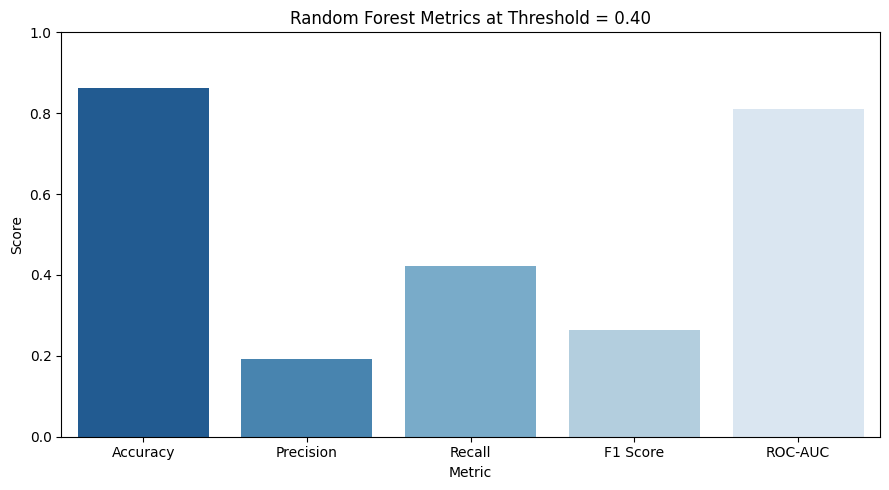

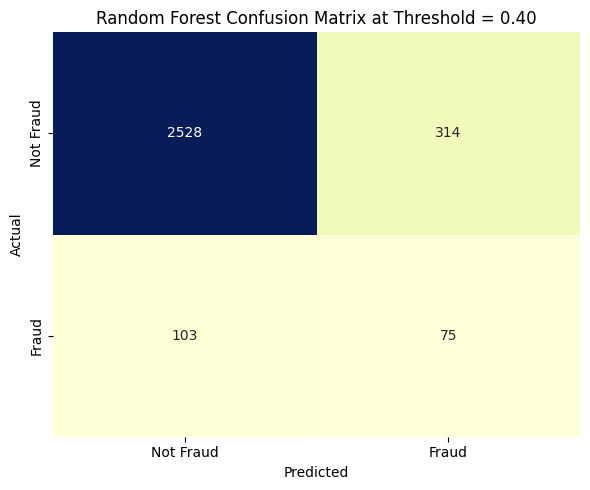

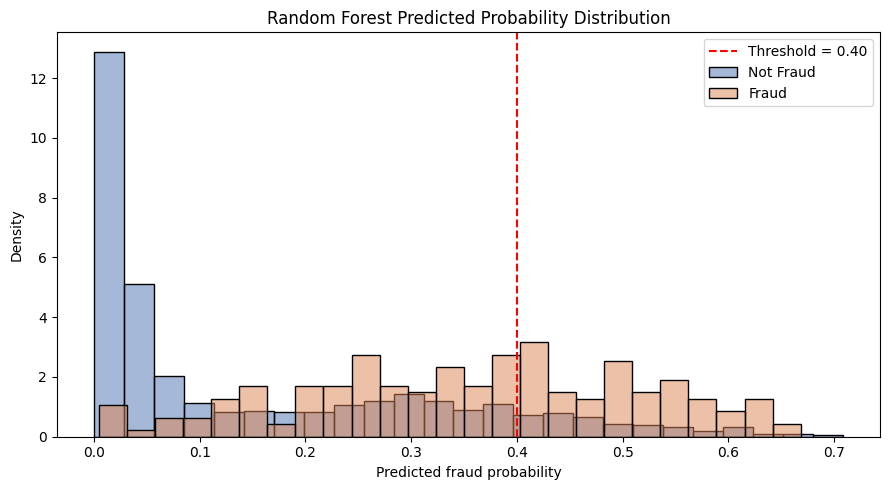

C:\Users\aaryan\AppData\Local\Temp\ipykernel_26252\3713505216.py:108: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rf_importances, x="Importance", y="Feature", palette="viridis")


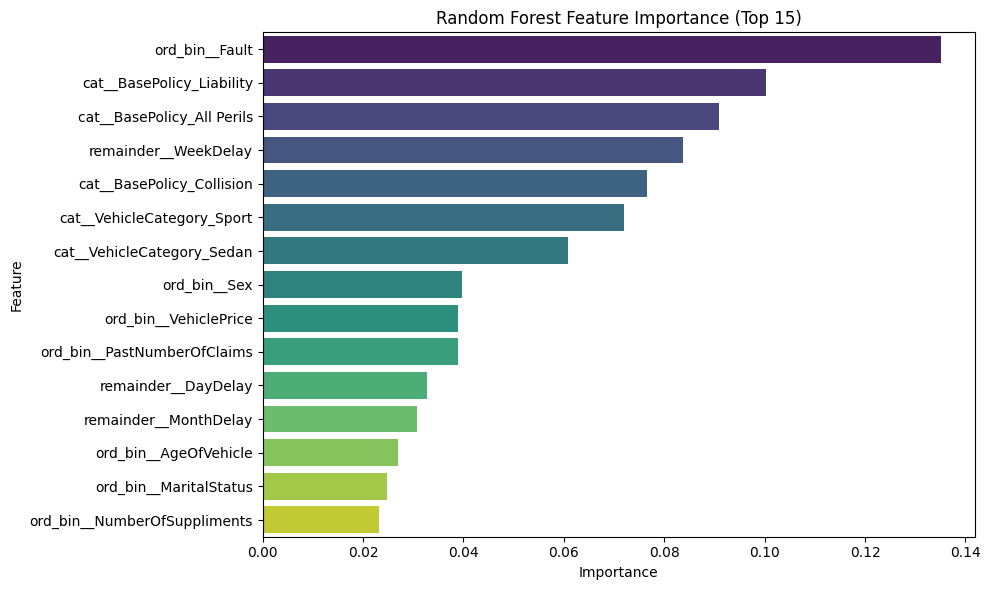

In [43]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features="sqrt",
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)

rf_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', rf_model)
])

rf_pipeline.fit(X_train, y_train)

rf_probs = rf_pipeline.predict_proba(X_test)[:, 1]
rf_threshold = 0.40
rf_pred = (rf_probs >= rf_threshold).astype(int)

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, zero_division=0)
rf_recall = recall_score(y_test, rf_pred, zero_division=0)
rf_f1 = f1_score(y_test, rf_pred, zero_division=0)
rf_roc_auc = roc_auc_score(y_test, rf_probs)

print(f"Random Forest metrics at threshold {rf_threshold:.2f}:")
print(f"Accuracy: {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall: {rf_recall:.4f}")
print(f"F1 Score: {rf_f1:.4f}")
print(f"ROC-AUC: {rf_roc_auc:.4f}")

rf_results = pd.DataFrame([
    {
        "Model": "Random Forest",
        "Threshold": rf_threshold,
        "Accuracy": rf_accuracy,
        "Precision": rf_precision,
        "Recall": rf_recall,
        "F1 Score": rf_f1,
        "ROC-AUC": rf_roc_auc,
    }
])

display(rf_results)

metric_values = {
    "Accuracy": rf_accuracy,
    "Precision": rf_precision,
    "Recall": rf_recall,
    "F1 Score": rf_f1,
    "ROC-AUC": rf_roc_auc,
}

plt.figure(figsize=(9, 5))
sns.barplot(
    x=list(metric_values.keys()),
    y=list(metric_values.values()),
    palette="Blues_r"
 )
plt.ylim(0, 1)
plt.title("Random Forest Metrics at Threshold = 0.40")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.tight_layout()
plt.show()

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    cbar=False,
    xticklabels=["Not Fraud", "Fraud"],
    yticklabels=["Not Fraud", "Fraud"]
 )
plt.title("Random Forest Confusion Matrix at Threshold = 0.40")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
sns.histplot(rf_probs[y_test == 0], bins=25, color="#4C72B0", label="Not Fraud", stat="density", alpha=0.5)
sns.histplot(rf_probs[y_test == 1], bins=25, color="#DD8452", label="Fraud", stat="density", alpha=0.5)
plt.axvline(rf_threshold, color="red", linestyle="--", label=f"Threshold = {rf_threshold:.2f}")
plt.title("Random Forest Predicted Probability Distribution")
plt.xlabel("Predicted fraud probability")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

rf_feature_names = rf_pipeline.named_steps["preprocessing"].get_feature_names_out()
rf_importances = pd.DataFrame({
    "Feature": rf_feature_names,
    "Importance": rf_pipeline.named_steps["model"].feature_importances_
}).sort_values("Importance", ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=rf_importances, x="Importance", y="Feature", palette="viridis")
plt.title("Random Forest Feature Importance (Top 15)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

#### Decision Tree

Decision Tree metrics at threshold 0.40:
Accuracy: 0.8003
Precision: 0.1522
Recall: 0.5225
F1 Score: 0.2357
ROC-AUC: 0.7994


,Model,Threshold,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Decision Tree,0.4,0.800331,0.152209,0.522472,0.235741,0.799363


C:\Users\aaryan\AppData\Local\Temp\ipykernel_26252\311908528.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


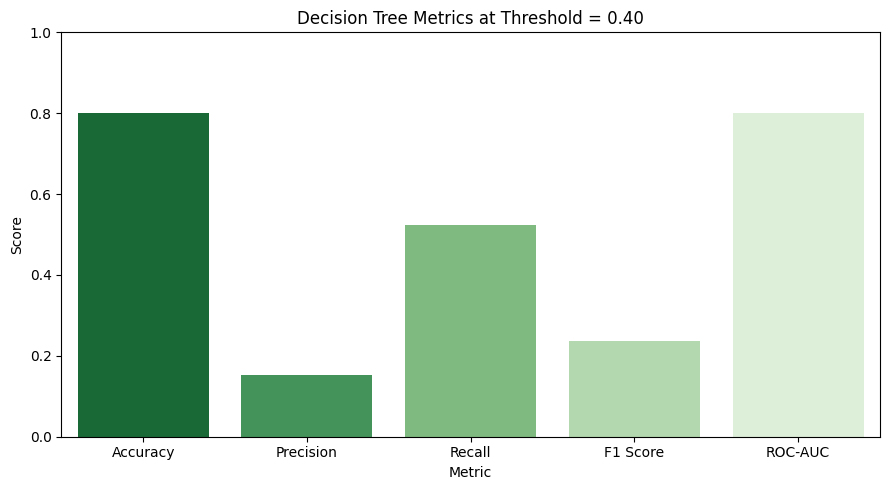

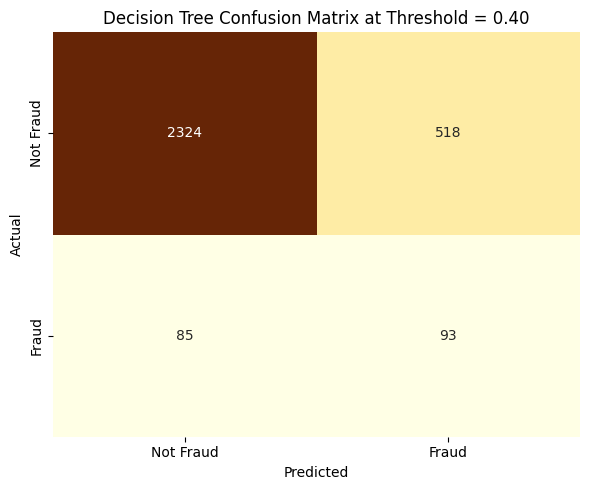

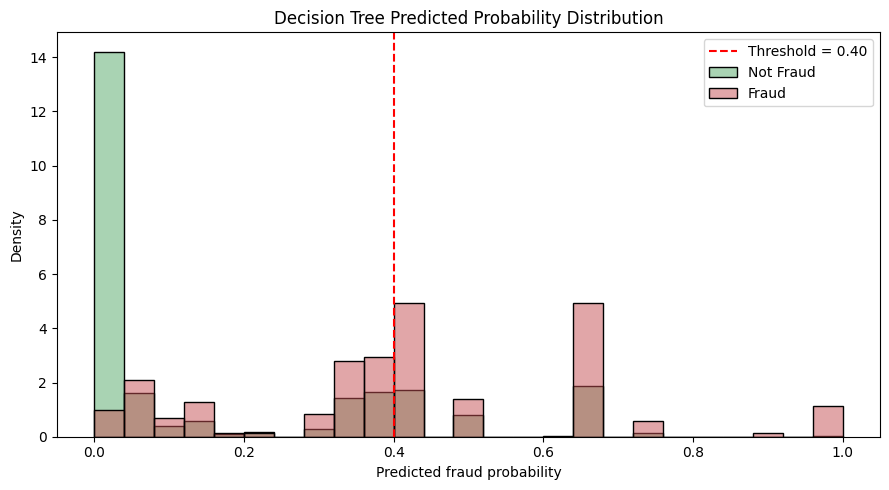

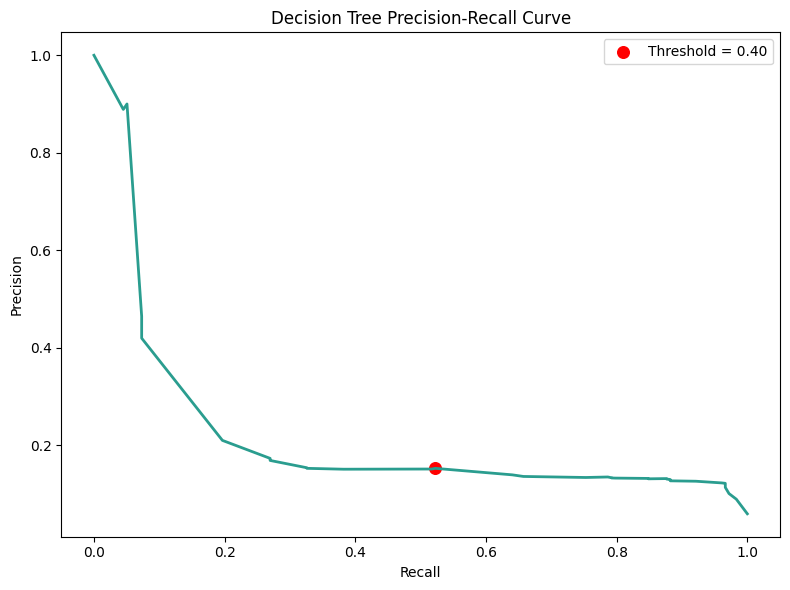

C:\Users\aaryan\AppData\Local\Temp\ipykernel_26252\311908528.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dt_importances, x="Importance", y="Feature", palette="viridis")


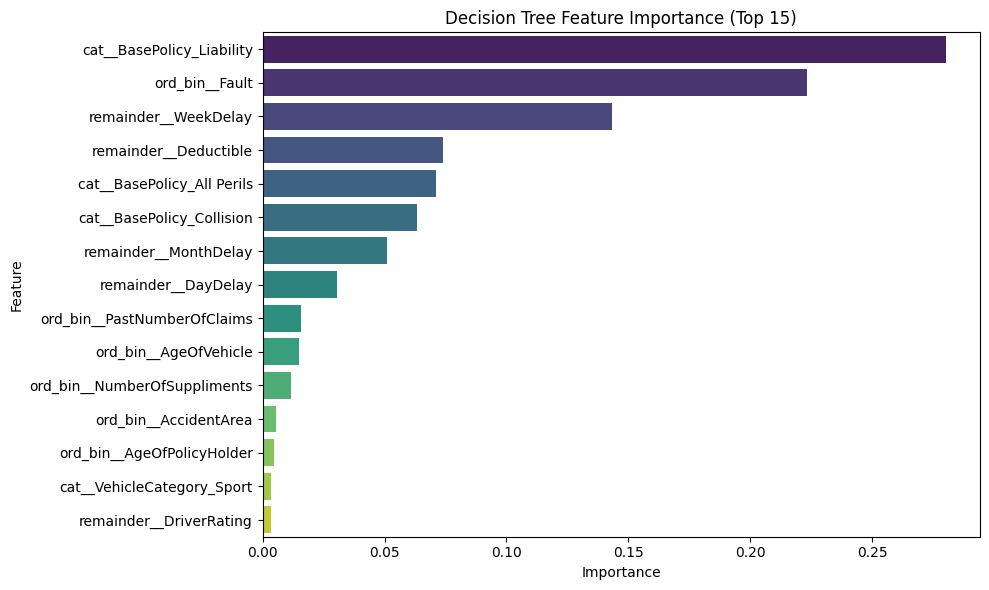

In [44]:
dt_model = DecisionTreeClassifier(
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=10,
    criterion="gini",
    random_state=42
)

dt_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', dt_model)
])

dt_pipeline.fit(X_train, y_train)

dt_probs = dt_pipeline.predict_proba(X_test)[:, 1]
dt_threshold = 0.40
dt_pred = (dt_probs >= dt_threshold).astype(int)

dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred, zero_division=0)
dt_recall = recall_score(y_test, dt_pred, zero_division=0)
dt_f1 = f1_score(y_test, dt_pred, zero_division=0)
dt_roc_auc = roc_auc_score(y_test, dt_probs)

print(f"Decision Tree metrics at threshold {dt_threshold:.2f}:")
print(f"Accuracy: {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall: {dt_recall:.4f}")
print(f"F1 Score: {dt_f1:.4f}")
print(f"ROC-AUC: {dt_roc_auc:.4f}")

dt_results = pd.DataFrame([
    {
        "Model": "Decision Tree",
        "Threshold": dt_threshold,
        "Accuracy": dt_accuracy,
        "Precision": dt_precision,
        "Recall": dt_recall,
        "F1 Score": dt_f1,
        "ROC-AUC": dt_roc_auc,
    }
])

display(dt_results)

metric_values = {
    "Accuracy": dt_accuracy,
    "Precision": dt_precision,
    "Recall": dt_recall,
    "F1 Score": dt_f1,
    "ROC-AUC": dt_roc_auc,
}

plt.figure(figsize=(9, 5))
sns.barplot(
    x=list(metric_values.keys()),
    y=list(metric_values.values()),
    palette="Greens_r"
 )
plt.ylim(0, 1)
plt.title("Decision Tree Metrics at Threshold = 0.40")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.tight_layout()
plt.show()

cm = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="YlOrBr",
    cbar=False,
    xticklabels=["Not Fraud", "Fraud"],
    yticklabels=["Not Fraud", "Fraud"]
 )
plt.title("Decision Tree Confusion Matrix at Threshold = 0.40")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
sns.histplot(dt_probs[y_test == 0], bins=25, color="#55A868", label="Not Fraud", stat="density", alpha=0.5)
sns.histplot(dt_probs[y_test == 1], bins=25, color="#C44E52", label="Fraud", stat="density", alpha=0.5)
plt.axvline(dt_threshold, color="red", linestyle="--", label=f"Threshold = {dt_threshold:.2f}")
plt.title("Decision Tree Predicted Probability Distribution")
plt.xlabel("Predicted fraud probability")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, dt_probs)

plt.figure(figsize=(8, 6))
plt.plot(recall_vals, precision_vals, color="#2A9D8F", linewidth=2)
plt.scatter(dt_recall, dt_precision, color="red", s=70, label=f"Threshold = {dt_threshold:.2f}")
plt.title("Decision Tree Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.show()

dt_feature_names = dt_pipeline.named_steps["preprocessing"].get_feature_names_out()
dt_importances = pd.DataFrame({
    "Feature": dt_feature_names,
    "Importance": dt_pipeline.named_steps["model"].feature_importances_
}).sort_values("Importance", ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=dt_importances, x="Importance", y="Feature", palette="viridis")
plt.title("Decision Tree Feature Importance (Top 15)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Final Prediction System

##### Random Forest

In [45]:
def predict_random_forest_fraud(user_input, threshold=0.40):
    expected_columns = X_train.columns.tolist()
    input_data = {column: X_train[column].mode().iloc[0] for column in expected_columns}
    input_data.update(user_input)

    input_df = pd.DataFrame([input_data], columns=expected_columns)

    probability_of_fraud = rf_pipeline.predict_proba(input_df)[:, 1][0]
    prediction = int(probability_of_fraud >= threshold)
    prediction_label = "Fraud" if prediction == 1 else "Not Fraud"

    print(f"Threshold: {threshold:.2f}")
    print(f"Fraud Probability: {probability_of_fraud:.4f}")
    print(f"Prediction: {prediction_label}")

    return {
        "threshold": threshold,
        "fraud_probability": probability_of_fraud,
        "prediction": prediction_label,
    }

sample_user_input = {
    "Age": 45,
    "Month": 1,
    "MonthClaimed": 1,
    "WeekOfMonth": 2,
    "WeekOfMonthClaimed": 3,
    "DayOfWeek": 2,
    "DayOfWeekClaimed": 4,
    "VehiclePrice": "60000+",
    "Days_Policy_Accident": "30+",
    "Days_Policy_Claim": "30+",
    "PastNumberOfClaims": "0",
    "AgeOfVehicle": "2-5",
    "AgeOfPolicyHolder": "40-50",
    "NumberOfCars": "1",
    "NumberOfSuppliments": "0",
    "AddressChange_Claim": "No",
    "VehicleCategory": "Sedan",
    "BasePolicy": "All Perils",
    "MaritalStatus": "Married",
    "AccidentArea": "Urban",
    "Sex": "Male",
    "Fault": "Policy Holder",
    "PoliceReportFiled": "No",
    "AgentType": "External",
    "LessAgeExpensiveVehicle": 0,
    "NoWitnessNoPoliceReport": "No",
    "MonthDelay": 0,
    "DayDelay": 0,
    "WeekDelay": 1
}

prediction_result = predict_random_forest_fraud(sample_user_input, threshold=0.40)
prediction_result

Threshold: 0.40
Fraud Probability: 0.4741
Prediction: Fraud


{'threshold': 0.4,
 'fraud_probability': np.float64(0.47405222598157365),
 'prediction': 'Fraud'}

##### Decision Tree

In [46]:
def predict_random_forest_fraud(user_input, threshold=0.40):
    expected_columns = X_train.columns.tolist()
    input_data = {column: X_train[column].mode().iloc[0] for column in expected_columns}
    input_data.update(user_input)

    input_df = pd.DataFrame([input_data], columns=expected_columns)

    probability_of_fraud = dt_pipeline.predict_proba(input_df)[:, 1][0]
    prediction = int(probability_of_fraud >= threshold)
    prediction_label = "Fraud" if prediction == 1 else "Not Fraud"

    print(f"Threshold: {threshold:.2f}")
    print(f"Fraud Probability: {probability_of_fraud:.4f}")
    print(f"Prediction: {prediction_label}")

    return {
        "threshold": threshold,
        "fraud_probability": probability_of_fraud,
        "prediction": prediction_label,
    }

sample_user_input = {
    "Age": 45,
    "Month": 1,
    "MonthClaimed": 1,
    "WeekOfMonth": 2,
    "WeekOfMonthClaimed": 3,
    "DayOfWeek": 2,
    "DayOfWeekClaimed": 4,
    "VehiclePrice": "60000+",
    "Days_Policy_Accident": "30+",
    "Days_Policy_Claim": "30+",
    "PastNumberOfClaims": "0",
    "AgeOfVehicle": "2-5",
    "AgeOfPolicyHolder": "40-50",
    "NumberOfCars": "1",
    "NumberOfSuppliments": "0",
    "AddressChange_Claim": "No",
    "VehicleCategory": "Sedan",
    "BasePolicy": "All Perils",
    "MaritalStatus": "Married",
    "AccidentArea": "Urban",
    "Sex": "Male",
    "Fault": "Policy Holder",
    "PoliceReportFiled": "No",
    "AgentType": "External",
    "LessAgeExpensiveVehicle": 0,
    "NoWitnessNoPoliceReport": "No",
    "MonthDelay": 0,
    "DayDelay": 0,
    "WeekDelay": 1
}

prediction_result = predict_random_forest_fraud(sample_user_input, threshold=0.40)
prediction_result

Threshold: 0.40
Fraud Probability: 0.4090
Prediction: Fraud


{'threshold': 0.4,
 'fraud_probability': np.float64(0.40904522613065325),
 'prediction': 'Fraud'}

#### Exporting Model

Firstly, we're gonna export the pipeline for the 2 models that we had created. However, we won't use the exact pipeline. We'll modify the pipeline for deployment purposes

In [58]:
rf_pipeline_deployment = Pipeline([
    ('preprocessing', preprocessor),
    ('model', rf_model)
])

rf_pipeline_deployment.fit(X_train, y_train)

joblib.dump(rf_pipeline, "output/rf_model.pkl")

['output/rf_model.pkl']

In [59]:
dt_pipeline_deployment = Pipeline([
    ('preprocessing', preprocessor),
    ('model', dt_model)
])

dt_pipeline_deployment.fit(X_train, y_train)

joblib.dump(dt_pipeline, "output/dt_model.pkl")

['output/dt_model.pkl']

Now we'll export the feature order

In [53]:
X_train.columns

Index(['AccidentArea', 'Sex', 'MaritalStatus', 'Age', 'Fault',
       'VehicleCategory', 'VehiclePrice', 'Deductible', 'DriverRating',
       'Days_Policy_Accident', 'Days_Policy_Claim', 'PastNumberOfClaims',
       'AgeOfVehicle', 'AgeOfPolicyHolder', 'PoliceReportFiled', 'AgentType',
       'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars',
       'BasePolicy', 'MonthDelay', 'DayDelay', 'WeekDelay',
       'NoWitnessNoPoliceReport', 'LessAgeExpensiveVehicle'],
      dtype='str')

In [55]:
feature_list = list(X_train.columns)
with open("output/feature_list.json", "w") as f:
    json.dump(feature_list, f)

Now we'll save the categorical features for dropdowns

In [57]:
cat_features = {}

for col in X.columns:
    cat_features[col] = list(df[col].astype(str).unique())
    
with open("output/cat_features.json", "w") as f:
    json.dump(cat_features, f)